# 🌍 Explore CMIP6 SSP5-8.5 Data via Zarr / Google Cloud Storage

This notebook loads CMIP6 climate model output directly from **cloud-optimised Zarr stores**
hosted on Google Cloud Storage — no local download required.

Two technologies do the heavy lifting:

| Technology | Role |
|---|---|
| [**CMIP6 Zarr catalogue**](https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv) | A CSV index of every available Zarr store — filter it like a dataframe |
| [**Zarr + fsspec**](https://zarr.readthedocs.io/) | Stream chunks of data lazily over HTTP from GCS — only what you actually use is downloaded |

**What we'll do**

1. Query the CMIP6 Zarr catalogue for near-surface air temperature (`tas`) from the **SSP5-8.5** scenario
2. Open the remote Zarr store lazily with `xarray` + `fsspec`
3. Map the temperature field on a proper geographic projection
4. Build an **area-weighted global-mean** temperature series
5. Compute the **warming anomaly** relative to a 2015–2025 baseline

> ⚠️ **Live data.** Cells stream data from Google Cloud Storage in real time.
> An internet connection is required; the first compute cell may take ~30–60 s depending on bandwidth.

## ⚙️ Setup

Imports plus a little plot styling so the figures look clean.

In [23]:
import numpy as np
import pandas as pd
import xarray as xr
import fsspec

import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

xr.set_options(display_style='html')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# --- light, consistent plot styling ---
mpl.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.size': 11,
})

## 🔎 Querying the CMIP6 Zarr catalogue

The CMIP6 Zarr catalogue is a single CSV file hosted on Google Cloud Storage. Each row points to
one Zarr store (one model × variable × experiment × member combination). We filter it like a
regular Pandas dataframe using the standard CMIP6 facets (`variable_id`, `experiment_id`,
`source_id`, `member_id`, `table_id`, `grid_label`).

In [5]:
df = pd.read_csv(
    "https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv"
)
df.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,ps,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
1,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rsds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
2,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlus,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
3,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
4,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,psl,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706


## 🔧 Choosing variables, experiments, ensembles, and timesteps

Before filtering the catalogue, it helps to understand what each facet means.

### 📊 Variable (`variable_id`)

CMIP6 variables follow the [CF conventions](https://cfconventions.org/) and are grouped into
**MIP tables** (e.g. `Amon` = monthly atmosphere).

| Variable ID | Long name | Units | MIP table |
|---|---|---|---|
| `tas` | 🌡️ Near-surface air temperature | K | `Amon` |
| `pr` | 🌧️ Precipitation | kg m⁻² s⁻¹ | `Amon` |
| `psl` | 💨 Sea-level pressure | Pa | `Amon` |
| `tos` | 🌊 Sea surface temperature | °C | `Omon` |
| `siconc` | 🧊 Sea ice area fraction | % | `SImon` |

### 🧪 Experiment (`experiment_id`)

Experiments define the **forcing scenario** applied to the model.

| Experiment | Activity | Period | Description |
|---|---|---|---|
| `historical` | `CMIP` | 1850–2014 | 📜 Observed forcings (GHGs, aerosols, land use) |
| `piControl` | `CMIP` | 500+ yrs | ⚖️ Pre-industrial control — constant 1850 forcings |
| `ssp126` | `ScenarioMIP` | 2015–2100 | 🌿 Low emissions — ~1.9 °C warming by 2100 |
| `ssp245` | `ScenarioMIP` | 2015–2100 | 🌤️ Intermediate emissions — ~2.7 °C warming by 2100 |
| `ssp370` | `ScenarioMIP` | 2015–2100 | ⚠️ High emissions — ~3.6 °C warming by 2100 |
| `ssp585` | `ScenarioMIP` | 2015–2100 | 🔥 Very high emissions ("business as usual") — ~4.4 °C warming by 2100 |

> The SSP numbers encode both a **Shared Socioeconomic Pathway** (1–5, from sustainability to fossil-fuel development) and a **radiative forcing level** by 2100 in W m⁻² (1.9, 2.6, 4.5, 7.0, 8.5).

### 🎲 Ensemble member (`member_id`)

The `member_id` tag `r<i>i<j>p<k>f<l>` identifies a specific run within a model's ensemble:

| Token | Meaning | Typical value |
|---|---|---|
| `r` | **R**ealization — different initial conditions | 1, 2, 3 … |
| `i` | **I**nitialization method | 1 |
| `p` | **P**hysics version | 1 |
| `f` | **F**orcing index | 1 |

`r1i1p1f1` is the standard first member. When multiple realizations exist (e.g. `r1`–`r10`), their
spread quantifies **internal variability**. How much the climate can differ by chance even under
identical external forcing.

### ⏱️ Timestep / Output frequency (`table_id`)

The `table_id` encodes both the **model realm** and the **output frequency** in a single string.
The prefix identifies the realm and the suffix the frequency:

| Table ID | Realm | Frequency | Typical use |
|---|---|---|---|
| `Amon` | ☁️ Atmosphere | Monthly | Standard atmospheric diagnostics (this notebook) |
| `Lmon` | 🌿 Land | Monthly | Soil moisture, vegetation, runoff |
| `Omon` | 🌊 Ocean | Monthly | SST, salinity, currents |
| `SImon` | 🧊 Sea ice | Monthly | Sea-ice concentration, thickness |
| `day` | ☁️ Atmosphere | Daily | Extremes, variability studies |
| `3hr` | ☁️ Atmosphere | 3-hourly | Precipitation intensity, diurnal cycle |
| `6hrLev` | ☁️ Atmosphere | 6-hourly on pressure levels | Reanalysis comparison, composites |
| `Ayr` | ☁️ Atmosphere | Annual | Long multi-century runs |
| `fx` | 🗺️ (any) | Time-invariant | Grid-cell area (`areacella`), orography, land mask |

> **Rule of thumb:** higher frequency = larger files, more compute. Monthly (`Amon`) is the best
> starting point for climatological studies. Switch to `day` or sub-daily only when your science
> question requires resolving shorter time scales (e.g. heat waves, diurnal precipitation).

### 🗂️ Grid label (`grid_label`)

The `grid_label` tells you **which grid version** of the data you are getting. Modelling centres
can publish the same variable on more than one grid:

| Label | Meaning | When to use |
|---|---|---|
| `gn` | **Native grid** — the model's own computational grid | Best for single-model analysis; preserves original resolution and structure |
| `gr` | **Regridded** — interpolated to a regular lat/lon grid by the modelling centre | Preferred for multi-model comparisons; all models on the same grid |
| `gr1`, `gr2` | Alternative regridded versions (different target resolutions) | Check the model's documentation for the exact resolution |
| `gnz` / `grz` | Zonal mean on native / regridded grid | Pre-computed meridional averages |

**Why it matters:** some models use non-standard grids internally (e.g. a cubed-sphere atmosphere
or a tripolar ocean). On those grids, `lat` and `lon` may not be simple 1-D coordinate arrays —
they can be 2-D. Choosing `gr` guarantees a regular grid that `xarray` handles transparently.

> In the catalogue above you can see both `gn` and `gr`/`gr1` rows for the same model. For a
> quick cross-model comparison, filter to a single label (e.g. `df[df.grid_label == "gn"]`) so
> you don't accidentally open the same data twice.

In [28]:
'''Load monthly near-surface air temperature (tas) from the SSP5-8.5 (ssp585) scenario,
ensemble member r1i1p1f1, on a regular grid, and return it as an xarray Dataset.
'''

variable = "tas"
experiment = "ssp585"
ensemble = "r1i1p1f1"
grid = "gr"

df_tas = df[
    (df.variable_id == variable)
    & (df.experiment_id == experiment)
    & (df.member_id == ensemble)
    & (df.table_id == "Amon")
    & (df.grid_label == grid)
]
df_tas


,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
279556,ScenarioMIP,IPSL,IPSL-CM6A-LR,ssp585,r1i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/ScenarioMIP/IPSL/IPSL-CM6A-LR...,NaN,20190903
295111,ScenarioMIP,NIMS-KMA,KACE-1-0-G,ssp585,r1i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/ScenarioMIP/NIMS-KMA/KACE-1-0...,NaN,20190920
360524,ScenarioMIP,CAS,FGOALS-f3-L,ssp585,r1i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/ScenarioMIP/CAS/FGOALS-f3-L/s...,NaN,20191013
420035,ScenarioMIP,EC-Earth-Consortium,EC-Earth3-Veg,ssp585,r1i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/ScenarioMIP/EC-Earth-Consorti...,NaN,20200225
425558,ScenarioMIP,EC-Earth-Consortium,EC-Earth3,ssp585,r1i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/ScenarioMIP/EC-Earth-Consorti...,NaN,20200310
449106,ScenarioMIP,THU,CIESM,ssp585,r1i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/ScenarioMIP/THU/CIESM/ssp585/...,NaN,20200605
498440,ScenarioMIP,E3SM-Project,E3SM-1-1,ssp585,r1i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/ScenarioMIP/E3SM-Project/E3SM...,NaN,20201117
500309,ScenarioMIP,EC-Earth-Consortium,EC-Earth3-Veg-LR,ssp585,r1i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/ScenarioMIP/EC-Earth-Consorti...,NaN,20201201
511768,ScenarioMIP,EC-Earth-Consortium,EC-Earth3-CC,ssp585,r1i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/ScenarioMIP/EC-Earth-Consorti...,NaN,20210113


## 📂 Opening a Zarr store from Google Cloud Storage

```python
ds = xr.open_zarr(fsspec.get_mapper(df_tas.zstore.iloc[0]), consolidated=True)
```

| Part | What it does |
|---|---|
| `df_tas.zstore.iloc[0]` | Picks the first `zstore` path from the filtered catalogue — a GCS URI like `gs://cmip6/CMIP6/ScenarioMIP/...` |
| `fsspec.get_mapper(...)` | Wraps the GCS path in a filesystem-agnostic key→bytes mapping so `xarray` can read remote storage (GCS, S3, HTTP, local) with the same interface |
| `xr.open_zarr(..., consolidated=True)` | Opens the Zarr store **lazily** — only metadata is fetched now; actual data arrays stream on demand. `consolidated=True` reads a single pre-built `.zmetadata` file instead of one HTTP request per variable, which is much faster over remote storage |

> No data is downloaded at this point. `ds` only holds coordinates, dimensions, and attributes.
> Arrays are loaded into memory only when you index or compute on them.

In [25]:
ds = xr.open_zarr(fsspec.get_mapper(df_tas.zstore.iloc[0]), consolidated=True)
ds

<xarray.Dataset> Size: 214MB
Dimensions:    (time: 1032, lat: 180, lon: 288, bnds: 2)
Coordinates:
  * time       (time) object 8kB 2015-01-16 12:00:00 ... 2100-12-16 12:00:00
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
  * bnds       (bnds) float64 16B 1.0 2.0
    lat_bnds   (lat, bnds) float64 3kB dask.array<chunksize=(180, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 5kB dask.array<chunksize=(288, 2), meta=np.ndarray>
    time_bnds  (time, bnds) object 17kB dask.array<chunksize=(1032, 2), meta=np.ndarray>
    height     float64 8B ...
Data variables:
    tas        (time, lat, lon) float32 214MB dask.array<chunksize=(600, 180, 288), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.0 UGRID-1.0
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  60225.0
    comment:                <null ref>
    ...                     ...
    title:                  NOAA GFDL GFDL-CM4 model output prepared for CMIP...
    tracking_id:            hdl:21.14100/991bc4a4-20d5-4a58-a451-6b3ea33116be
    variable_id:            tas
    variant_info:           N/A
    variant_label:          r1i1p1f1
    status:                 2019-08-13;created;by nhn2@columbia.edu

In [26]:
ds.tas

<xarray.DataArray 'tas' (time: 1032, lat: 180, lon: 288)> Size: 214MB
dask.array<open_dataset-tas, shape=(1032, 180, 288), dtype=float32, chunksize=(600, 180, 288), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 8kB 2015-01-16 12:00:00 ... 2100-12-16 12:00:00
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
    height   float64 8B ...
Attributes:
    cell_measures:  area: areacella
    cell_methods:   area: time: mean
    interp_method:  conserve_order2
    long_name:      Near-Surface Air Temperature
    original_name:  tas
    standard_name:  air_temperature
    units:          K

## 💾 Data footprint

How large is the full dataset, in MB per simulation year?

In [51]:
print(f'Data footprint: {ds.nbytes / 1e6 / (ds.sizes["time"] / 12):.2f} MB per simulation year')
print(f'Total data size: {ds.nbytes / 1e9:.2f} GB')

Data footprint: 2.49 MB per simulation year
Total data size: 0.21 GB


## 🗺️ Map a single month

Instead of a bare lat/lon grid, we render the field on a **Robinson projection** with coastlines
and a labelled colorbar. We pick **January 2050** from the SSP5-8.5 scenario as a snapshot of
mid-century projected warming.

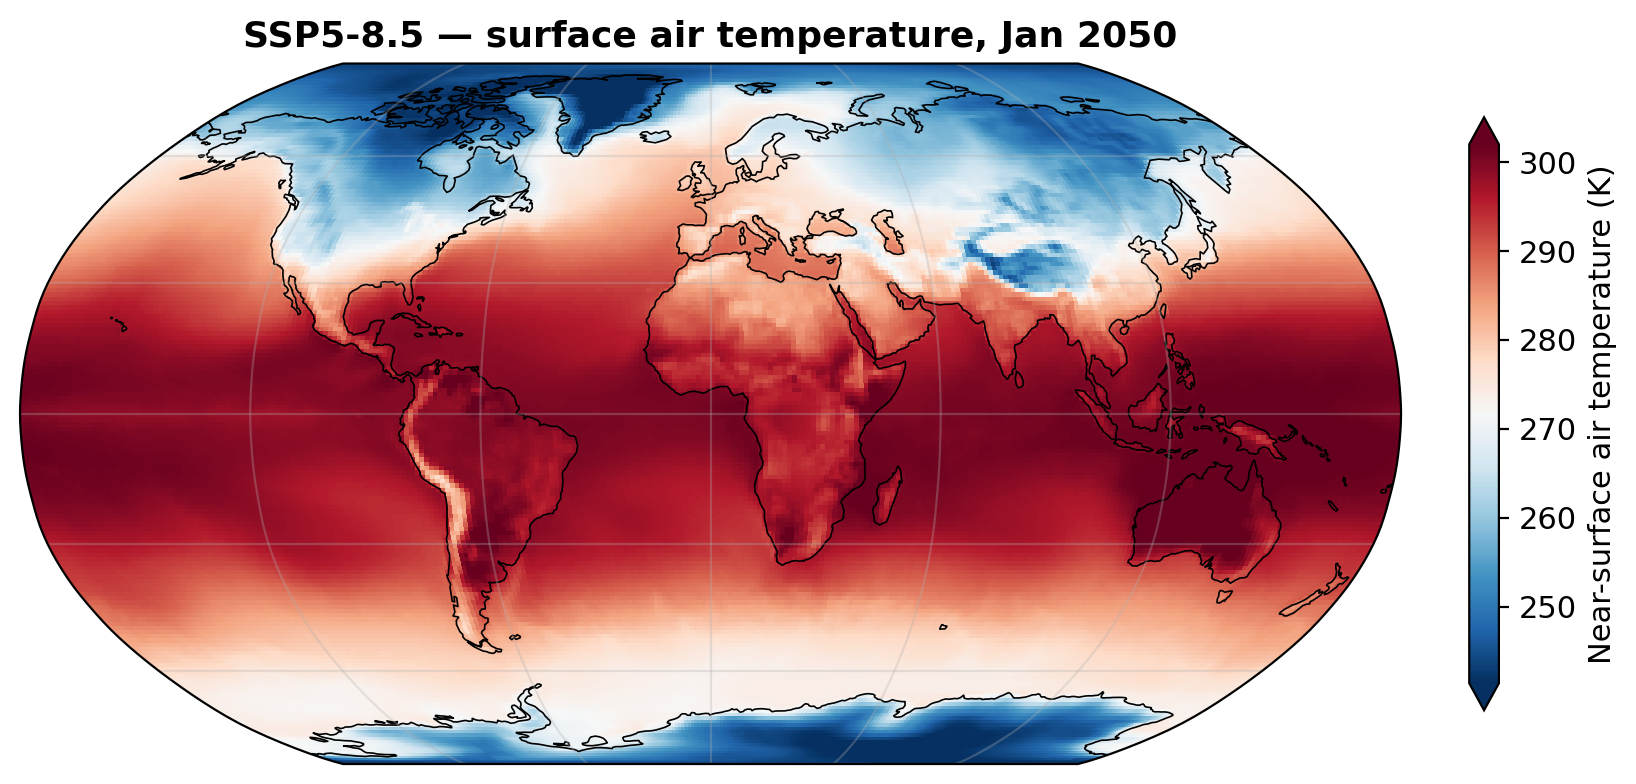

In [32]:
snapshot = ds.tas.sel(time="2050-01").squeeze()

fig = plt.figure(figsize=(11, 5.5))
ax = plt.axes(projection=ccrs.Robinson())

p = snapshot.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    robust=True,
    cbar_kwargs={
        "label": "Near-surface air temperature (K)",
        "shrink": 0.7,
        "pad": 0.04,
    },
)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.gridlines(alpha=0.3)
ax.set_global()
ax.set_title("SSP5-8.5 — surface air temperature, Jan 2050", fontweight="bold")
plt.show()


### 🔍 Plotting a regional subset

To zoom into a specific region, subset the array **before** plotting with `.sel(lat=slice(...), lon=slice(...))`.
This streams only the relevant chunk from the remote store instead of the full global field.

| Change vs global map | Why |
|---|---|
| `.sel(lat=slice(...), lon=slice(...))` | Clips the array to the bounding box — less data, faster render |
| `ccrs.PlateCarree()` | Flat projection works better than Robinson for regional views |
| `ax.set_extent([W, E, S, N])` | Zooms the map frame to the region of interest |
| `draw_labels=True` on gridlines | Adds lat/lon tick labels on the axes |
| `cfeature.BORDERS` | Shows country borders — useful at regional scale |

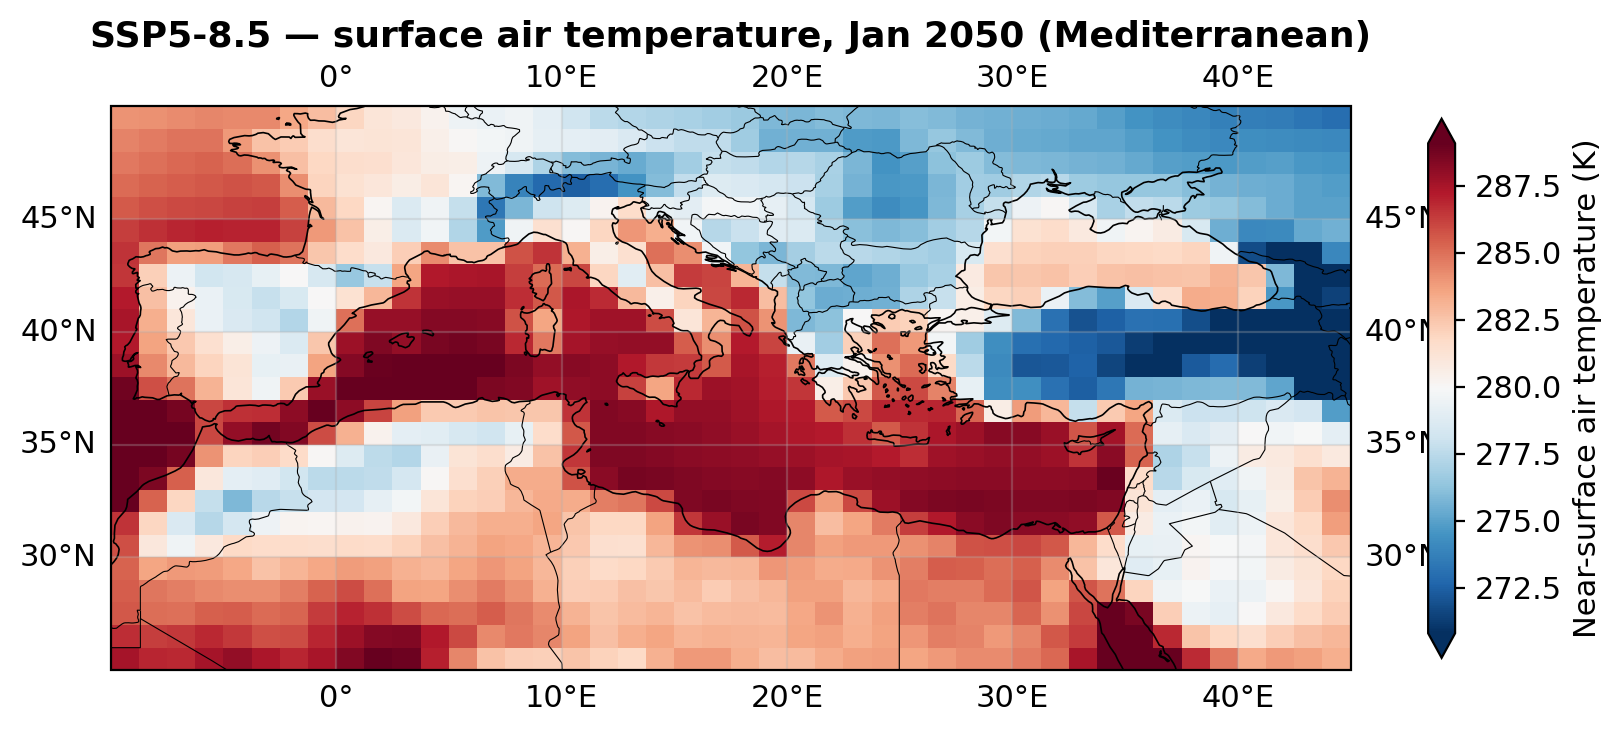

In [ ]:
# e.g. Mediterranean region
lon_min, lon_max = -10, 45
lat_min, lat_max = 25, 50

ds_180 = ds.assign_coords(lon=(ds.lon + 180) % 360 - 180).sortby("lon")
subset = (
    ds_180.tas.sel(time="2050-01", lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
    .squeeze()
    .sortby("lat")
)


fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

subset.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    robust=True,
    cbar_kwargs={"label": "Near-surface air temperature (K)", "shrink": 0.7},
)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.gridlines(draw_labels=True, alpha=0.3)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.set_title(
    "SSP5-8.5 — surface air temperature, Jan 2050 (Mediterranean)", fontweight="bold"
)
plt.show()


### Seasonal climatology

A four-panel seasonal mean over the full **2015–2100** SSP5-8.5 projection. This triggers a real
computation across all timesteps streamed from Google Cloud Storage, so give it a moment.

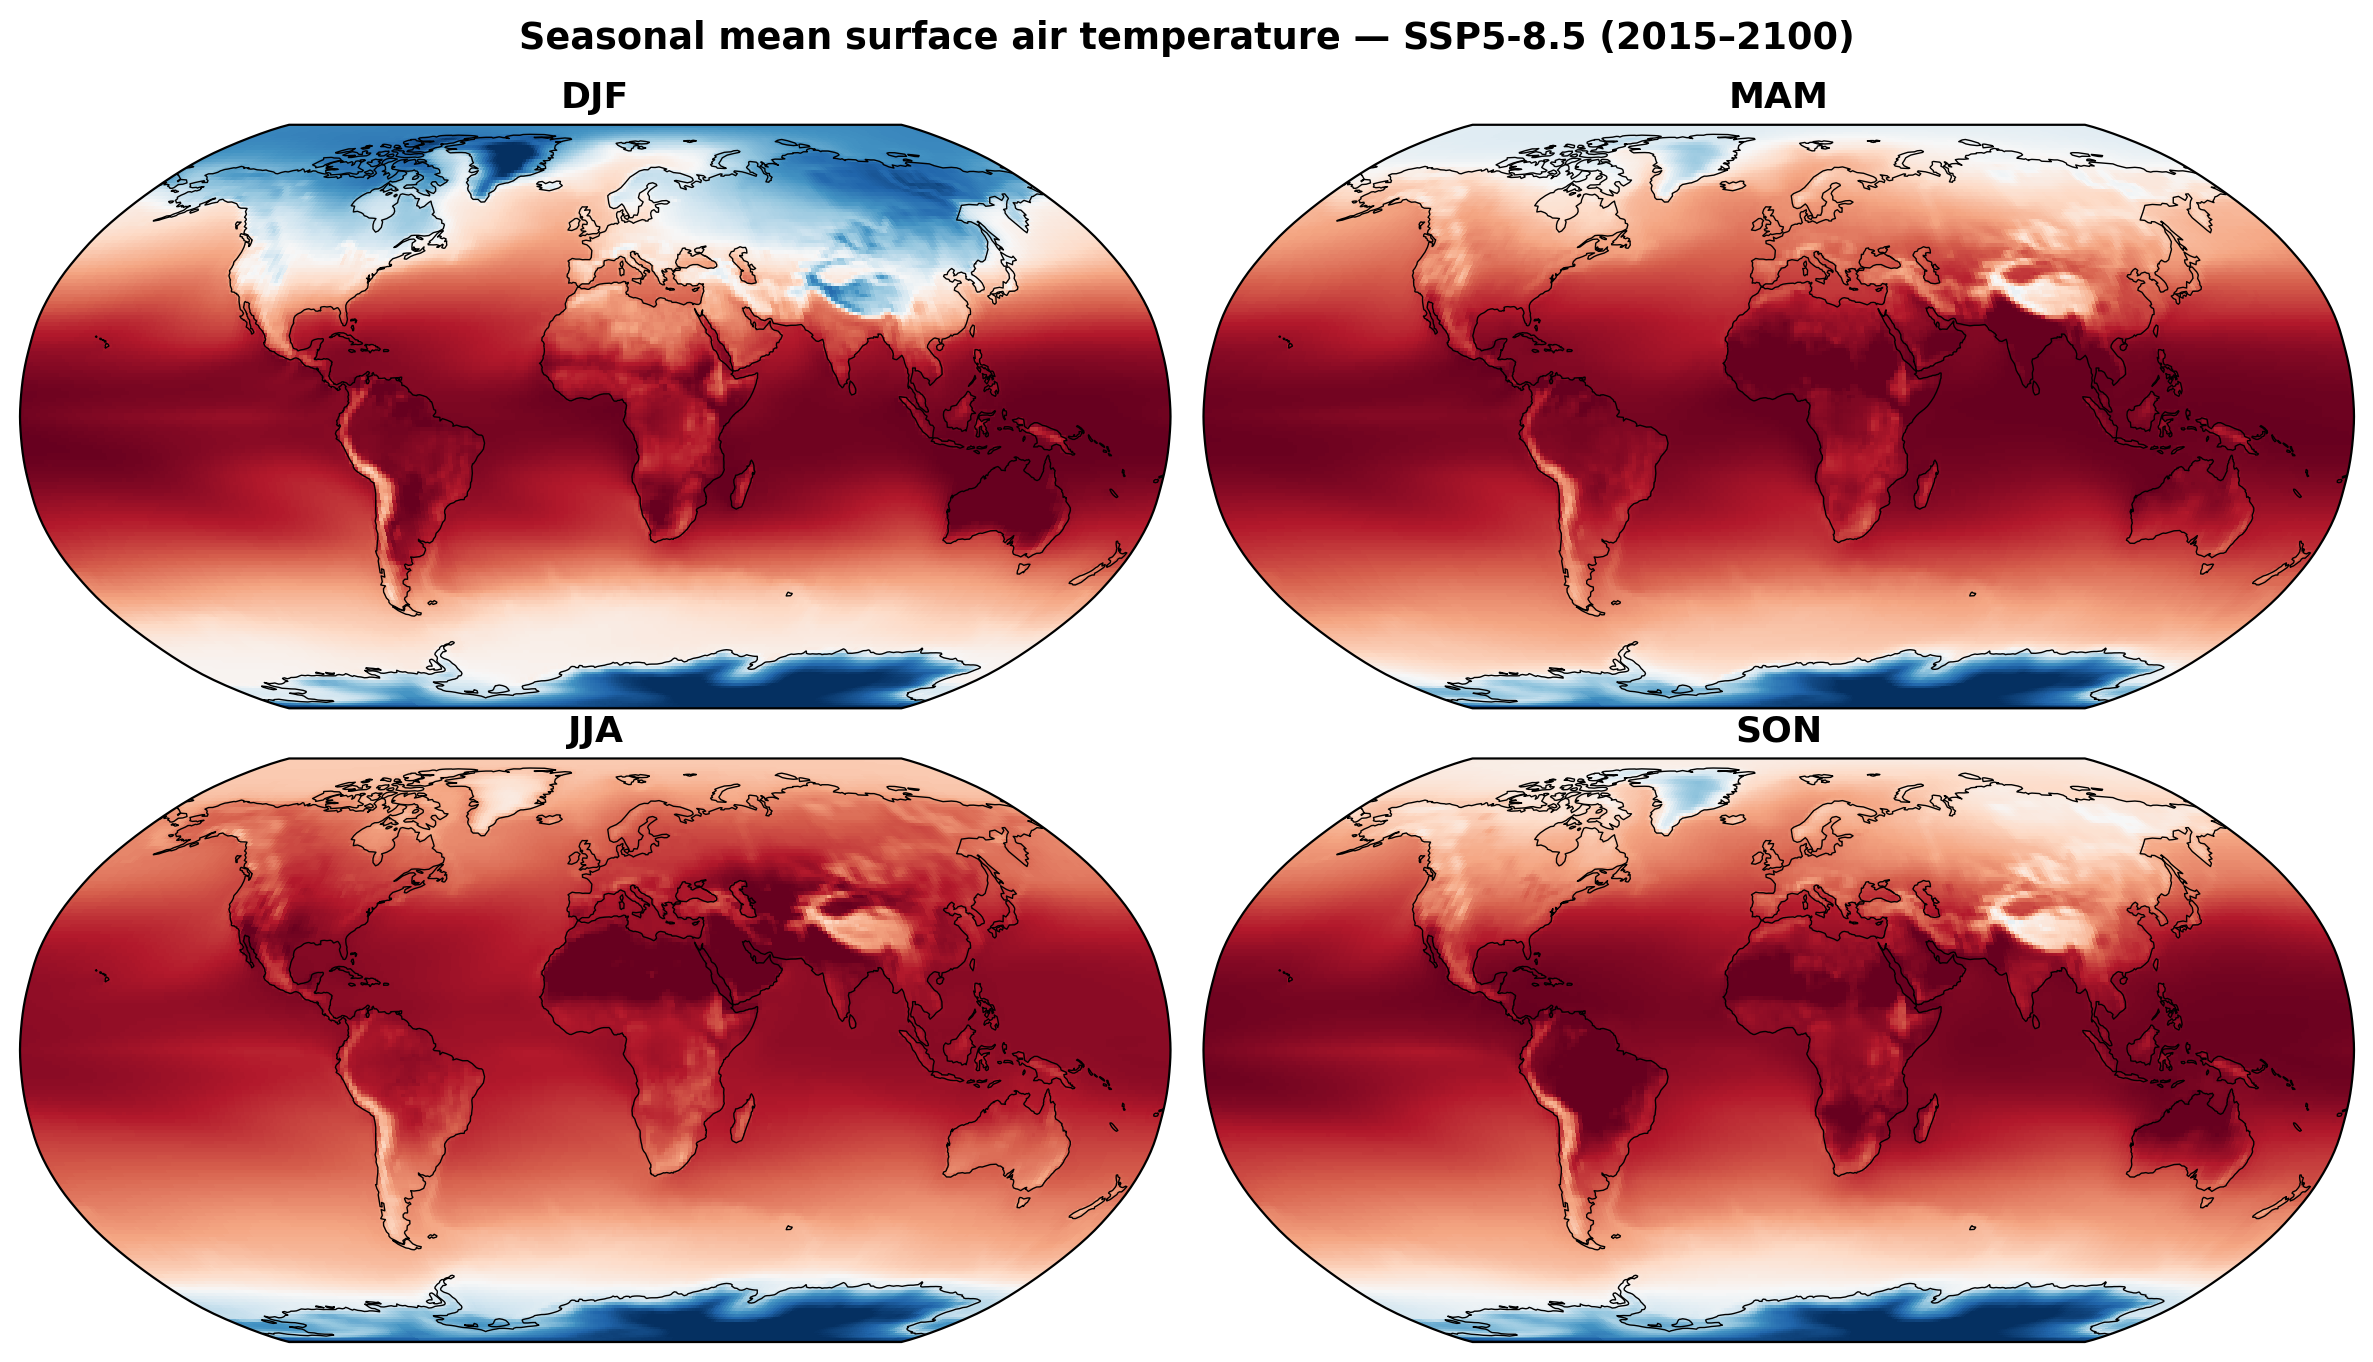

In [37]:
seasonal = ds.tas.groupby("time.season").mean("time")
seasons = ["DJF", "MAM", "JJA", "SON"]

fig, axes = plt.subplots(
    2, 2, figsize=(12, 7), subplot_kw={"projection": ccrs.Robinson()}
)
for ax, season in zip(axes.flat, seasons):
    seasonal.sel(season=season).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        robust=True,
        add_colorbar=False,
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_global()
    ax.set_title(season)

fig.suptitle(
    "Seasonal mean surface air temperature — SSP5-8.5 (2015–2100)",
    fontweight="bold",
    y=0.98,
)
plt.tight_layout()
plt.show()


## 🌡️ Area-weighted global-mean temperature

A simple average over grid cells is biased. Cells near the poles are much smaller than at the equator.
Since `ds` is on a regular lat/lon grid (`gr`), cell area is proportional to `cos(lat)`, so we use
xarray's built-in `weighted()` method instead of loading a separate `areacella` file.

In [40]:
weights = np.cos(np.deg2rad(ds_180.lat))
ta_timeseries = ds_180.tas.weighted(weights).mean(dim=["lon", "lat"])


Data loads lazily as dask arrays; here we trigger the computation explicitly.

In [41]:
%time ta_timeseries = ta_timeseries.load()

CPU times: total: 3.55 s
Wall time: 36.4 s


### 📉 Visualising the global-mean time series

We plot the raw monthly values in light grey and overlay a **12-month rolling mean** to filter out
the seasonal cycle and highlight the long-term warming trend.

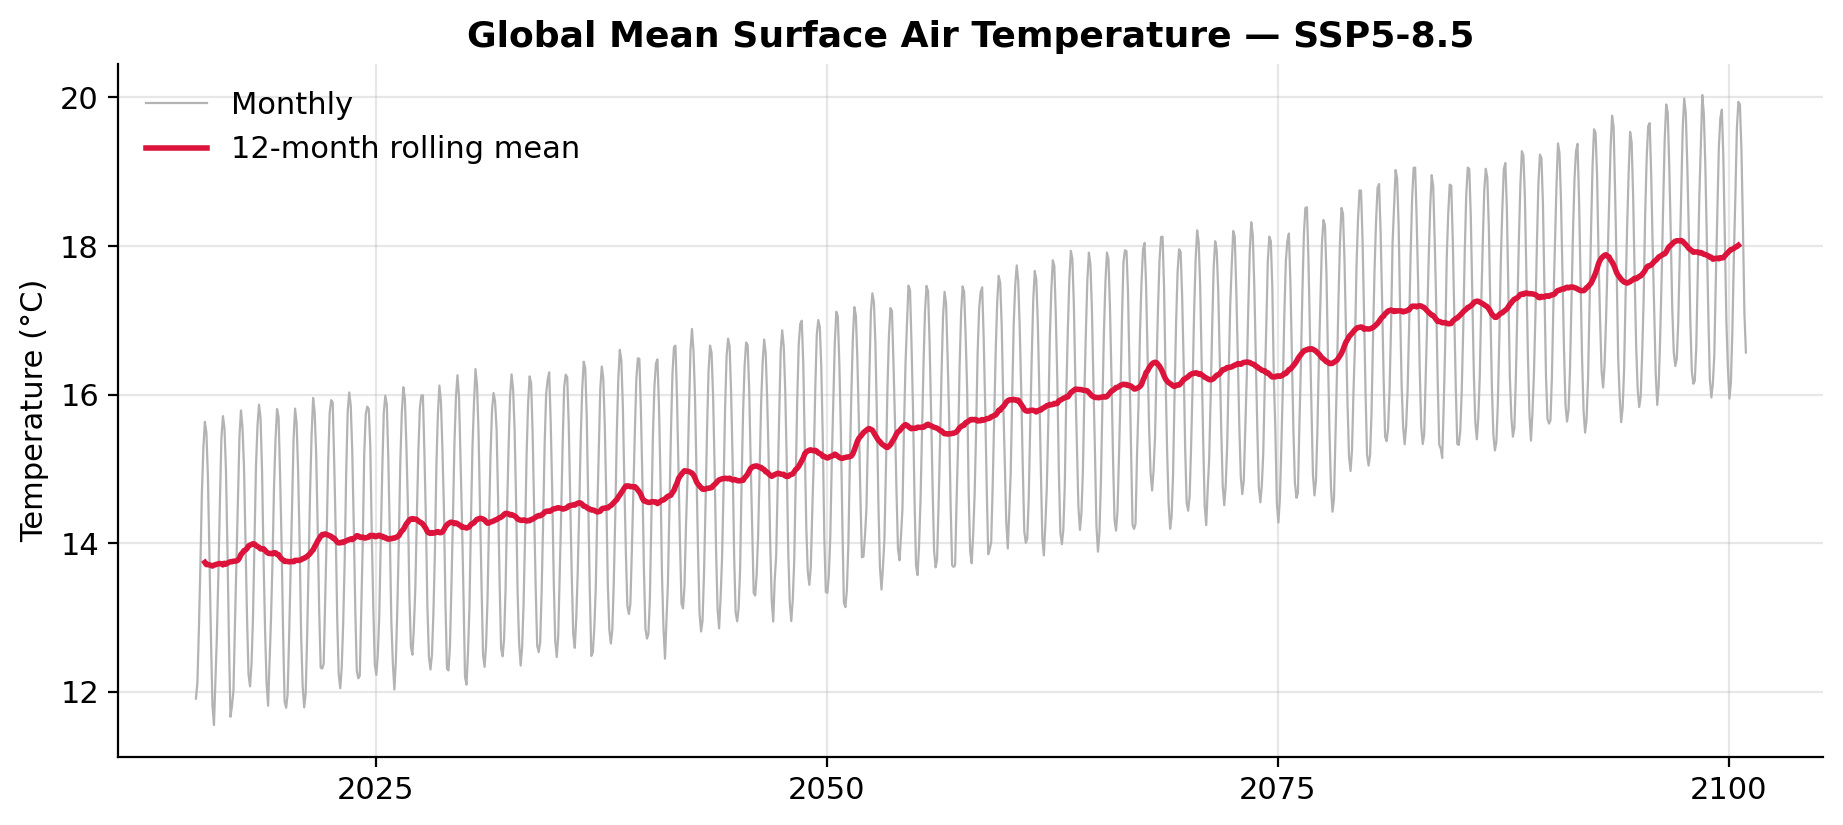

In [44]:
fig, ax = plt.subplots(figsize=(11, 4.5))

ta_timeseries_C = ta_timeseries - 273.15 # convert from K to °C

ta_timeseries_C.plot(ax=ax, color='0.7', lw=0.8, label='Monthly')
ta_timeseries_C.rolling(time=12, center=True).mean().plot(
    ax=ax, color='crimson', lw=2, label='12-month rolling mean')

ax.set_title('Global Mean Surface Air Temperature — SSP5-8.5')
ax.set_ylabel('Temperature (°C)')
ax.set_xlabel('')
ax.legend(frameon=False)
plt.show()

### 📍 Time series at a specific location

Instead of a global mean, extract the temperature at a single grid point using `.sel()` with
`method='nearest'` — xarray snaps to the closest grid cell to your target coordinates.


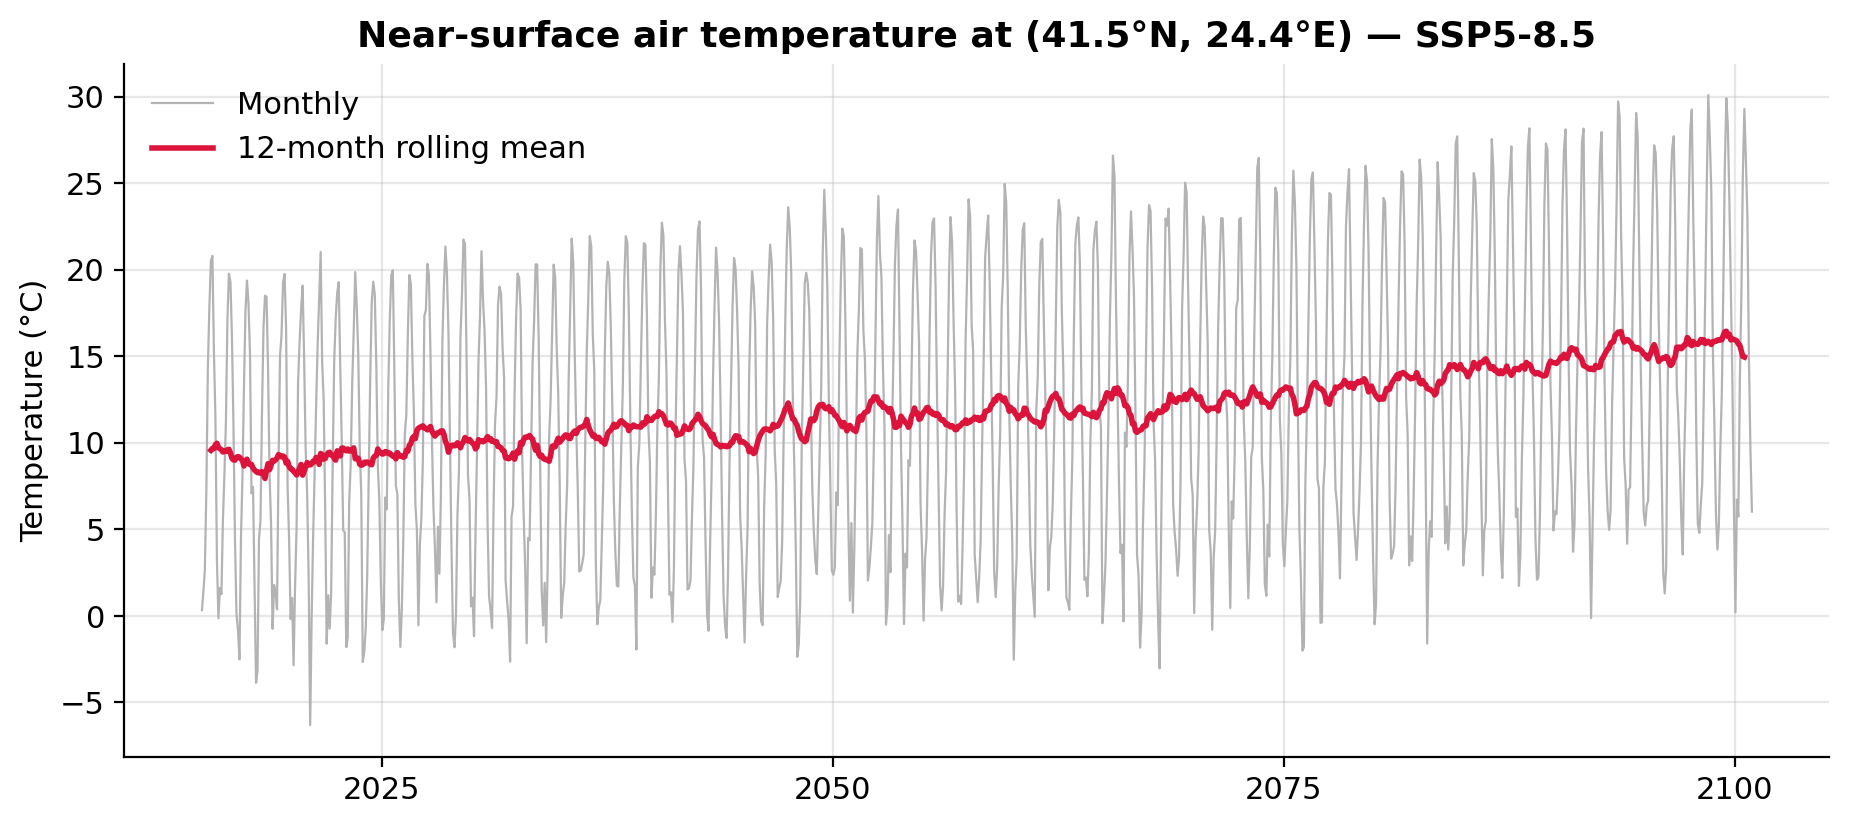

In [46]:
# Target location — change to any lat/lon you like
target_lat = 41.133  # Xanthi, Greece
target_lon = 24.883

point = ds_180.tas.sel(lat=target_lat, lon=target_lon, method="nearest")

point_C = point - 273.15  # convert from K to °C


fig, ax = plt.subplots(figsize=(11, 4.5))
point_C.plot(ax=ax, color="0.7", lw=0.8, label="Monthly")
point_C.rolling(time=12, center=True).mean().plot(
    ax=ax, color="crimson", lw=2, label="12-month rolling mean"
)

actual_lat = float(point.lat)
actual_lon = float(point.lon)
ax.set_title(
    f"Near-surface air temperature at ({actual_lat:.1f}°N, {actual_lon:.1f}°E) — SSP5-8.5",
    fontweight="bold",
)
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("")
ax.legend(frameon=False)
plt.show()


## 📈 Warming relative to early projection period

Climate signals read more clearly as **anomalies**. We take a **2015–2025** reference baseline
from the start of the SSP5-8.5 run, subtract it, and average to annual values —
warm years above the line, cool years below.

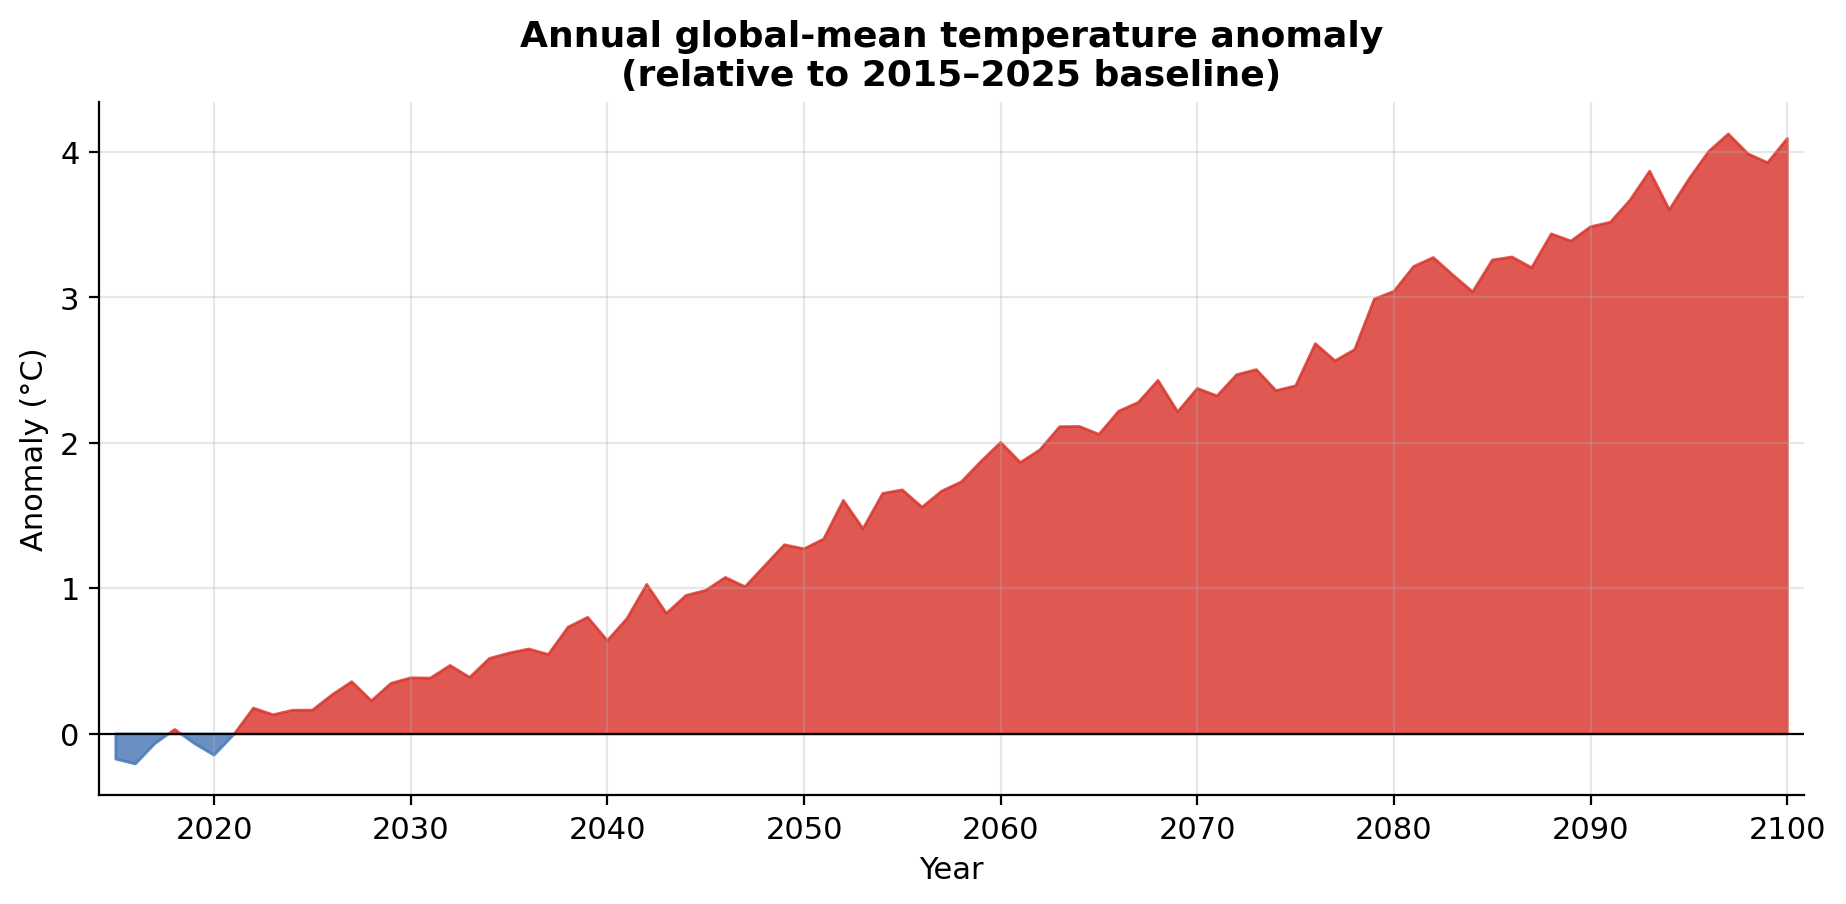

Total warming (2015–2025 → 2025–2035): 0.37 °C


In [47]:
baseline = ta_timeseries_C.sel(time=slice('2015', '2025')).mean()
anom = ta_timeseries_C - baseline
annual = anom.groupby('time.year').mean()


fig, ax = plt.subplots(figsize=(11, 4.5))
years = annual['year'].values
vals = annual.values

ax.fill_between(years, vals, where=(vals >= 0), color='#d73027', alpha=0.8, interpolate=True)
ax.fill_between(years, vals, where=(vals < 0),  color='#4575b4', alpha=0.8, interpolate=True)
ax.axhline(0, color='k', lw=0.8)

ax.set_title('Annual global-mean temperature anomaly\n(relative to 2015–2025 baseline)')
ax.set_ylabel('Anomaly (°C)')
ax.set_xlabel('Year')
ax.margins(x=0.01)
plt.show()

print(f'Total warming (2015–2025 → 2025–2035): '
      f'{float(annual.sel(year=slice(2025, 2035)).mean()):.2f} °C')

---
## Summary

We queried the CMIP6 Zarr catalogue for `tas` from the **SSP5-8.5** scenario (`r1i1p1f1`, `gr` grid),
streamed the data lazily from Google Cloud Storage, mapped it on geographic projections,
computed a **cosine-weighted global-mean** temperature series, and extracted point and regional subsets.

**Try next**

- Swap `source_id` to compare models (e.g. `'EC-Earth3'`, `'KACE-1-0-G'`, `'FGOALS-f3-L'`)
- Change `experiment_id` to `'ssp126'` or `'ssp245'` to compare emission pathways
- Concatenate multiple ensemble members (`r1`, `r2`, `r3` …) and plot their spread
- Extend the anomaly analysis by chaining the `historical` run (1850–2014) before